# Generative LMC pipeline — controlled lyric × music congruence

**Experimental arm of the Lyric-Music Congruence (LMC) project.**

We manufacture stimuli in which LMC is under experimental control. Eight fixed
choruses (each written to convey one of Plutchik's eight high-intensity emotions)
are each set to eight musical emotions, giving an **8 × 8 grid of 64 choruses**.
The diagonal is *congruent* (lyric emotion = music emotion); off-diagonal cells are
*incongruent* by degree. Music is generated locally with **ACE-Step 1.5**.

Pipeline: build MuLan emotion **anchors** → tune eight caption **recipes** →
generate **64** choruses → **validate** with MuLan (+ optional CLAP) → descriptive
**statistics & plots**.

> **ACE-Step conditions on text, not embeddings.** It has no slot for a raw target
> embedding, so each musical emotion is a caption / bpm / key recipe, empirically
> *tuned* so its audio lands closest to that emotion's MuLan anchor.

> **Kernel:** select **Python (lmc)** — the same env that runs MuLan/CLAP in the
> observational arm. ACE-Step 1.5 does **not** run in this env — it lives in its
> own `uv`-managed environment and we talk to it over its REST API server.

## 0 · Setup

`DRY_RUN` (env `LMCGEN_DRY_RUN`, default **1**) synthesises cheap emotion-dependent
audio instead of calling ACE-Step, so the whole pipeline runs in seconds for a
plumbing check. **Set `LMCGEN_DRY_RUN=0` for the real study.** In dry-run every number
is meaningless (MOCK) and figures are labelled as such.

**For real generation, ACE-Step 1.5 is a separate process, started separately.**
`pip install acestep` does not work — there is no such PyPI package. Instead, in a
**separate terminal**:

```bash
cd /path/to/ACE-Step-1.5          # your git-cloned, uv-sync'd install
uv run python -m acestep.api_server        # or ./start_api_server_macos.sh
```

Leave that running, then set `LMCGEN_DRY_RUN=0` below and confirm the server is
reachable with `acestep.check_server()` before generating anything. We talk to it
over HTTP (not a Python import) specifically so ACE-Step's own dependency stack
never has to be installed into this `lmc` conda env.

> ⚠️ The pipeline is **resumable by file existence** — cached clips/embeddings are
> reused. When you flip `LMCGEN_DRY_RUN` between 1 and 0, run
> `pipeline.clean_generated()` **once** so mock and real artifacts don't mix.

In [2]:
import os, sys, logging
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))   # make `lmc` and `lmcgen` importable

from dotenv import load_dotenv
load_dotenv()   # reads .env in this notebook's directory (GEMINI_API_KEY, SUNO_API_KEY, SPOTIFY_*, ...)

os.environ["LMCGEN_DRY_RUN"] = "0"        # 0 = REAL ACE-Step generation; comment out (or =1) for dry-run
# os.environ["LMCGEN_USE_CLAP"] = "1"       # <-- add the independent CLAP validator
os.environ["ACESTEP_API_URL"] = "http://127.0.0.1:8001"  # REST API port (NOT 7860, the Gradio UI)

from lmcgen import config as C, emotions as emo, lyrics as lyr, mulan, acestep, pipeline, analysis
# pipeline.clean_generated()   # <-- run ONCE when switching between dry-run and real
from lmc.utils import setup_logging
setup_logging(logging.INFO)

C.ensure_dirs()
MOCK = C.DRY_RUN
print(C.summary())
if not MOCK:
    acestep.check_server()    # fails fast with instructions if the server isn't up

11:32:09 | INFO | lmcgen.acestep | ACE-Step API server confirmed at http://127.0.0.1:8001 (37 routes; schema at http://127.0.0.1:8001/docs).


Repo root      : /Users/budge.13/Desktop/Music Analysis
Generation dir : /Users/budge.13/Desktop/Music Analysis/data/generation
Results dir    : /Users/budge.13/Desktop/Music Analysis/results/generation
Figures dir    : /Users/budge.13/Desktop/Music Analysis/analysis/output/figures/generation
Emotions       : ecstasy, admiration, terror, amazement, grief, loathing, rage, vigilance
Grid           : 8 lyrics x 8 music = 64 hooks (~13s each, single genre)
ACE-Step model : acestep-v15-base via http://127.0.0.1:8001 (steps=50, guidance=9.0, thinking=False)
Lyric screening: on (Whisper small, best of 3 takes by WER)
Recipe tuning  : off (3 candidates x 1 seeds)
CLAP validator : off
DRY_RUN        : False   (REAL ACE-Step generation)


## 1 · The design — eight emotions in ONE genre, on the affect circumplex

All eight emotions are rendered as **90s alternative rock** with a **fixed lead voice**; emotion is varied *within* the genre via tempo, mode (major/minor), dynamics and intensity — not by switching styles. This removes the earlier emotion↔genre confound, equalises lyric intelligibility, and keeps the singer roughly constant. Plutchik valence/arousal coordinates (Russell 1980; Scherer 2005) remain the interpretable fallback; note some petals (admiration, vigilance, amazement, loathing) are still hard to separate inside one genre.

In [3]:
import pandas as pd
design = pd.DataFrame(
    [{"emotion": e.name, "plutchik": e.plutchik_dyad, "valence": e.valence,
      "arousal": e.arousal, "bpm": e.bpm, "key": e.keyscale,
      "caption (default)": e.caption[:60] + "…"} for e in emo.ALL]
).set_index("emotion")
design

,plutchik,valence,arousal,bpm,key,caption (default)
emotion,,,,,,
ecstasy,joy,0.92,0.85,150,E major,"Lead vocal: one female alto, warm and natural,..."
admiration,trust,0.78,0.42,92,G major,"Lead vocal: one female alto, warm and natural,..."
terror,fear,0.10,0.90,156,D minor,"Lead vocal: one female alto, warm and natural,..."
amazement,surprise,0.62,0.85,120,A major,"Lead vocal: one female alto, warm and natural,..."
grief,sadness,0.10,0.20,68,C minor,"Lead vocal: one female alto, warm and natural,..."
loathing,disgust,0.15,0.55,100,F minor,"Lead vocal: one female alto, warm and natural,..."
rage,anger,0.12,0.95,168,E minor,"Lead vocal: one female alto, warm and natural,..."
vigilance,anticipation,0.55,0.65,132,A minor,"Lead vocal: one female alto, warm and natural,..."


11:32:15 | INFO | lmcgen.analysis |   figure: /Users/budge.13/Desktop/Music Analysis/analysis/output/figures/generation/valence_arousal.png


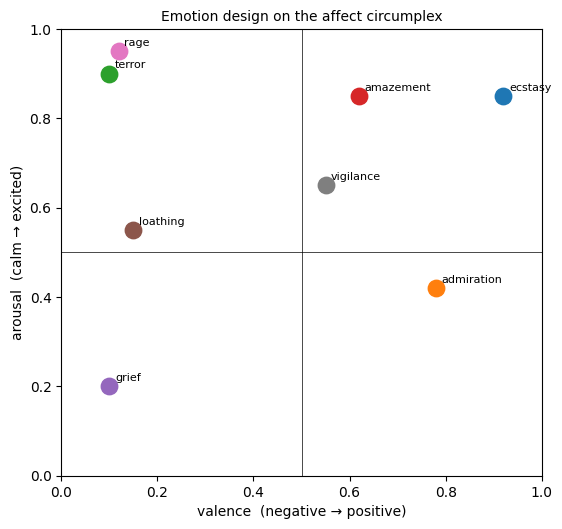

In [4]:
_ = analysis.plot_valence_arousal(mock=False)   # the design map (no clips yet)
import matplotlib.pyplot as plt; plt.show()

## 2 · The eight choruses (lyric stimuli) + why each targets its emotion

Original, clean, non-derivative lyrics; word choice grounded in each emotion's
Plutchik / NRC EmoLex vocabulary.

In [5]:
for ch in lyr.ALL:
    print(f"── {ch.emotion.upper()} " + "─" * (40 - len(ch.emotion)))
    print(ch.text.strip())
    print(f"   rationale: {ch.rationale}\n")

── ECSTASY ─────────────────────────────────
Hands to the sky, we're burning gold tonight
        Alive, alive, everything's alight
   rationale: Joy words (gold, alive, burning, light, sky) at high valence/arousal give a euphoric, celebratory hook.

── ADMIRATION ──────────────────────────────
I'd follow you through fire, through the cold
        You're the truest heart I'll ever hold
   rationale: Trust/devotion words (follow, truest, heart, hold) convey warm, loyal admiration.

── TERROR ──────────────────────────────────
Run, don't look back, it's closing in
        Something in the dark knows where I've been
   rationale: Fear cues (run, dark, closing in) build dread and panic at high arousal, low valence.

── AMAZEMENT ───────────────────────────────
Out of nowhere, it took my breath away
        Eyes wide open, nothing looks the same today
   rationale: Surprise/awe words (out of nowhere, breath away, eyes wide) mark sudden amazement.

── GRIEF ──────────────────────────────────

### 2a · Evidence #1 — lexical alignment (model-independent)

Count each emotion's lexicon words in each chorus. The target emotion should win
its own row. This needs no model — it is a transparent, auditable check.

In [6]:
lex = lyr.lexical_alignment()
print("lexical argmax accuracy:", lex["correct"].mean())
lex

lexical argmax accuracy: 1.0


,ecstasy,admiration,terror,amazement,grief,loathing,rage,vigilance,predicted,correct
chorus_emotion,,,,,,,,,,
ecstasy,4,0,0,0,0,0,1,0,ecstasy,True
admiration,0,2,0,0,1,0,1,0,admiration,True
terror,0,0,2,0,0,0,0,0,terror,True
amazement,0,0,0,1,0,0,0,0,amazement,True
grief,0,0,0,0,2,0,0,0,grief,True
loathing,0,0,0,0,0,3,0,0,loathing,True
rage,1,0,0,0,0,1,2,0,rage,True
vigilance,0,0,0,0,0,0,1,3,vigilance,True


## 3 · PHASE 1 — generate the 64 choruses  *(ACE-Step only; MuLan NOT loaded)*

**Memory-safe design.** On a 16 GB Mac you must not hold MuLan and the ACE-Step
3.5B model in RAM at once — that OOMs and can crash the machine. So generation and
validation are split into two phases that never overlap:

- **Phase 1 (this cell):** `generate_all()` talks to the ACE-Step server over HTTP
  and downloads clips. It does **not** load MuLan, so this process stays tiny and
  ACE-Step is the only large model in memory.
- **Phase 2 (below):** after you *stop the ACE-Step server*, load MuLan and validate.

`generate_all()` is resumable — clips are cached, so if it's interrupted just re-run
it and it continues. Recipe **tuning is off by default** (it would need MuLan running
at the same time); each emotion uses its hand-written default caption. Per-clip
timing + ETA are logged so you can watch progress.

> Before running: start the ACE-Step **API server** (port 8001) in a separate
> terminal. On your fanless 16 GB Air, also disable ACE-Step's optional LM to save
> memory (we don't use it — `thinking=False`):
> ```bash
> cd /path/to/ACE-Step-1.5
> ACESTEP_INIT_LLM=false ./start_api_server_macos.sh
> ```

**Lyric screening (new).** Each hook is generated as *best-of-N takes*: every take is transcribed with Whisper and scored for word error rate (WER) against the target lyric, and the clearest take is kept. Install the ASR backend once in the lmc env:

```
pip install faster-whisper
```

Disable with env LMCGEN_ASR=0, or tune config.ASR (model_size, max_takes, accept_wer). faster-whisper is small (CPU/int8) so it runs fine alongside the ACE-Step server.

In [7]:
# Phase 1: generation only — no MuLan in this process.
recipes = pipeline.generate_all()      # tune=False by default; set LMCGEN_TUNE=1 only on a big-RAM box
print("generated clips in", C.AUDIO_DIR)

11:32:33 | INFO | lmcgen.acestep | ACE-Step API server confirmed at http://127.0.0.1:8001 (37 routes; schema at http://127.0.0.1:8001/docs).
11:32:34 | INFO | lmcgen.pipeline | Recipes: using default per-emotion captions (tuning off).
11:32:34 | INFO | lmcgen.pipeline | Generating 64 hooks (dry_run=False, WER screening=True)…
11:32:34 | INFO | lmcgen.pipeline | [1/64] lyric=ecstasy x music=ecstasy …


KeyboardInterrupt: 

### ⏸️ Now STOP the ACE-Step server

In the terminal running the API server, press **Ctrl-C** to free its several GB so
MuLan has room. (Skip in dry-run — there's no server.) Then run Phase 2.

## 4 · PHASE 2 — validate with MuLan  *(loads MuQ-MuLan; server not needed)*

`validate_all()` loads MuLan (+ CLAP if enabled), builds the emotion **anchors**,
embeds the 8 chorus texts and all 64 clips, and assembles the tidy results. Models
are freed between passes to cap peak memory. This is the only phase that loads MuLan.

In [7]:
out = pipeline.validate_all()          # models = ['mulan'] (+ 'clap' if LMCGEN_USE_CLAP=1)
grid = out["grid"]
print("rows:", len(grid), "| models:", sorted(grid['model'].unique()))
grid.head()

11:38:54 | INFO | lmc.embeddings | Loading MuQ-MuLan on mps…
11:38:54 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/OpenMuQ/MuQ-MuLan-large/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
11:38:54 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/OpenMuQ/MuQ-MuLan-large/2e01c796b71dca71b45251384c04cd7b237c9020/config.json "HTTP/1.1 200 OK"
11:38:54 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/OpenMuQ/MuQ-large-msd-iter/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
11:38:54 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/OpenMuQ/MuQ-large-msd-iter/0562a57814f6f8bbd9fdea0a25921a2fce1a841a/config.json "HTTP/1.1 200 OK"
/opt/anaconda3/envs/lmc/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
11:38:55 | I

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
11:38:56 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/OpenMuQ/MuQ-MuLan-large/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
11:38:56 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/OpenMuQ/MuQ-MuLan-large/resolve/main/pytorch_model.bin "HTTP/1.1 302 Found"
11:38:59 | INFO | lmcgen.mulan | Anchors[mulan]: embedding 8 emotion prompt sets…
11:38:59 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/xlm-roberta-base/resolve/main/config.json "HTTP/1.1 200 

rows: 64 | models: ['mulan']


,model,lyric_emotion,music_emotion,congruent,seed,path,lmc_cross,music_anchor_cos,pred_music_emotion,wer,transcript,anchor_cos__ecstasy,anchor_cos__admiration,anchor_cos__terror,anchor_cos__amazement,anchor_cos__grief,anchor_cos__loathing,anchor_cos__rage,anchor_cos__vigilance
0,mulan,ecstasy,ecstasy,True,20260702,/Users/budge.13/Desktop/Music Analysis/data/ge...,0.276187,0.181812,admiration,0.714286,"Heads to the sky, we're burning gold tonight ...",0.181812,0.276319,-0.026784,0.079529,0.269497,0.027781,0.055766,-0.077820
1,mulan,ecstasy,admiration,False,20260703,/Users/budge.13/Desktop/Music Analysis/data/ge...,0.064418,-0.033850,amazement,0.964286,Thank you very much for watching. I'll see yo...,-0.087249,-0.033850,-0.039149,0.071672,-0.164907,0.010757,-0.083305,-0.036943
2,mulan,ecstasy,terror,False,20260704,/Users/budge.13/Desktop/Music Analysis/data/ge...,0.216382,0.080007,amazement,0.964286,HEAD! There may go tonight. Ah!,0.068962,0.118497,0.080007,0.221147,-0.036315,0.135525,0.189708,-0.051633
3,mulan,ecstasy,amazement,False,20260705,/Users/budge.13/Desktop/Music Analysis/data/ge...,0.133346,0.001645,ecstasy,0.857143,Hands to the sky,0.142237,0.087759,-0.157449,0.001645,-0.095837,-0.159727,-0.149353,-0.141067
4,mulan,ecstasy,grief,False,20260706,/Users/budge.13/Desktop/Music Analysis/data/ge...,0.264380,0.287544,grief,0.714286,Hands to the sky Hands to the sky,0.225585,0.283169,0.106790,0.153732,0.287544,0.124479,0.150703,-0.014578


### 4a · Evidence #2 — lyric ↔ anchor cosine (embedding, text-side only)

Each chorus's MuLan **text** embedding vs. the eight emotion anchors — the target
emotion should be nearest. Computed on the text side only, so it's independent of the
music generation. (MuLan reads valence well but blurs fine emotion — see the README
KNOWN ISSUE; the lexical check in §2a is the model-independent cross-check.)

11:39:29 | INFO | lmcgen.analysis |   figure: /Users/budge.13/Desktop/Music Analysis/analysis/output/figures/generation/lyric_alignment_mulan.png


embedding argmax accuracy: 0.25


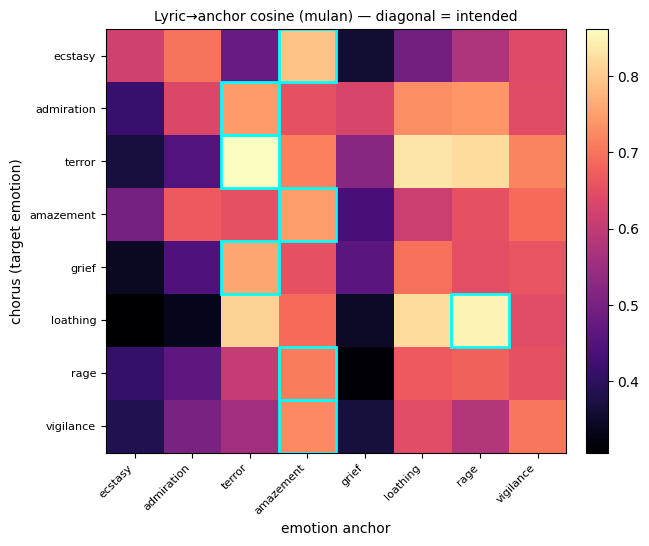

,ecstasy,admiration,terror,amazement,grief,loathing,rage,vigilance,predicted,correct
chorus_emotion,,,,,,,,,,
ecstasy,0.619,0.700,0.478,0.791,0.360,0.494,0.574,0.641,amazement,False
admiration,0.416,0.635,0.746,0.651,0.631,0.730,0.739,0.644,terror,False
terror,0.371,0.450,0.862,0.715,0.523,0.833,0.821,0.721,terror,True
amazement,0.499,0.668,0.653,0.747,0.434,0.614,0.653,0.690,amazement,True
grief,0.345,0.445,0.758,0.653,0.459,0.695,0.650,0.659,terror,False
loathing,0.307,0.336,0.811,0.689,0.349,0.823,0.849,0.646,rage,False
rage,0.410,0.466,0.605,0.711,0.315,0.667,0.679,0.654,amazement,False
vigilance,0.386,0.504,0.557,0.726,0.368,0.646,0.581,0.705,amazement,False


In [8]:
lyric_embed = out["lyric_embed"]["mulan"]
print("embedding argmax accuracy:", lyric_embed["correct"].mean())
_ = analysis.plot_lyric_alignment(lyric_embed, "mulan", mock=MOCK)
import matplotlib.pyplot as plt; plt.show()
lyric_embed.round(3)

## 5 · Descriptive statistics — is LMC being captured?

Three tests:
1. **Headline contrast** — congruent (diagonal) vs incongruent (off-diagonal) realised
   LMC = `cos(audio, lyric-text)`. Congruent should be higher.
2. **Graded congruence** — realised LMC vs *designed* congruence
   (`cos(anchor_lyric, anchor_music)`); a positive correlation means the continuous
   signal, not just the diagonal, is recovered.
3. **Manipulation check** — did each music emotion's audio land on its own anchor?
   (Partly circular for MuLan since tuning optimised this; the CLAP column, if enabled,
   is the independent read.)

In [9]:
summ = analysis.lmc_summary(grid)
display(summ.round(4))

anchor_sim = {mk: pd.read_csv(C.RESULTS_DIR / f"anchor_similarity_{mk}.csv", index_col=0)
              for mk in grid["model"].unique()}
grad = analysis.congruence_gradient(grid, anchor_sim)
display(grad.round(4))

acc, per_emotion = analysis.manipulation_accuracy(grid)
display(acc.round(4))
display(per_emotion.round(4))

,congruent_mean,congruent_sd,incongruent_mean,incongruent_sd,gap,cohens_d,welch_t,p_value,n_congruent,n_incongruent
model,,,,,,,,,,
mulan,0.2144,0.104,0.1488,0.0952,0.0656,0.6815,1.6851,0.1272,8,56


,pearson_r,spearman_r,n
model,,,
mulan,0.0177,-0.0339,64


,accuracy,n
model,,
mulan,0.1406,64


,model,music_emotion,accuracy,mean_anchor_cos,n
0,mulan,admiration,0.375,0.1338,8
1,mulan,amazement,0.000,0.0177,8
2,mulan,ecstasy,0.125,0.1071,8
3,mulan,grief,0.250,0.1025,8
4,mulan,loathing,0.000,0.0484,8
5,mulan,rage,0.375,0.0822,8
6,mulan,terror,0.000,0.0620,8
7,mulan,vigilance,0.000,-0.0033,8


### 5a · Lyric intelligibility (word error rate)

How cleanly the sung lyrics match the target, per cell. Screening keeps the best of N takes, so these are the *retained* WERs. Sung-audio WER is inherently high (25–50% even when clearly intelligible), so read it as a relative screen and a go/no-go signal for whether ACE-Step is good enough vs. a paid tool.

overall: {'median_wer': 0.833, 'mean_wer': 0.795, 'worst_wer': 1.0, 'n_cells': 64, 'frac_over_0.30': 0.984}


,mean,max
music_emotion,,
ecstasy,0.834,1.000
admiration,0.692,0.964
terror,0.837,1.000
amazement,0.730,1.000
grief,0.885,1.000
loathing,0.833,1.000
rage,0.791,1.000
vigilance,0.758,0.967


,mean,max
lyric_emotion,,
ecstasy,0.786,0.964
admiration,0.837,0.944
terror,0.712,1.000
amazement,0.867,1.000
grief,0.838,1.000
loathing,0.723,1.000
rage,0.886,0.971
vigilance,0.712,0.967


11:39:29 | INFO | lmcgen.analysis |   figure: /Users/budge.13/Desktop/Music Analysis/analysis/output/figures/generation/wer_heatmap.png


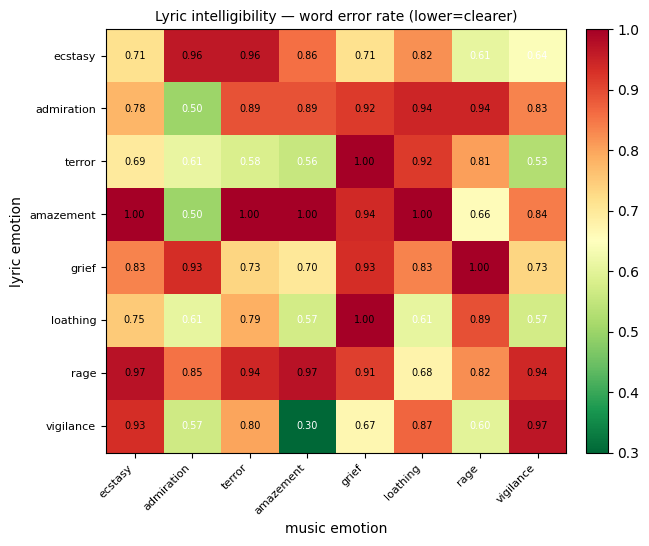

In [10]:
wer = analysis.wer_summary(grid)
if wer is None:
    print('No WER recorded (screening was off / dry-run).')
else:
    overall, by_music, by_lyric = wer
    print('overall:', {k: round(v, 3) for k, v in overall.items()})
    display(by_music.round(3)); display(by_lyric.round(3))
    fig = analysis.plot_wer_heatmap(grid, mock=MOCK)
    import matplotlib.pyplot as plt; plt.show()

## 5b · Tier-1 re-scoring — fair WER + valence/arousal  *(no regeneration)*

Two measurement fixes applied to the *existing* 64 clips (needs Whisper + librosa, NOT MuLan or the ACE-Step server):

- **Fair WER** — transcribe with hallucination guards (Whisper invents "thanks for watching" on buried-vocal clips), score against the *single* hook (crediting one or two sung repeats), and flag vocal-absent clips.
- **Valence/Arousal instrument** — MuLan can't see emotion once genre is fixed, so measure audio VA from acoustics (librosa, reusing `lmc.mood`) and lyric VA from a VAD lexicon, and score congruence in VA space.

`va.py`'s lyric lexicon is a compact stopgap — swap in full NRC-VAD or a GoEmotions/VAD model for a thesis.

13:44:10 | INFO | lmcgen.asr | Loading Whisper (small, cpu/int8) for lyric screening…
13:44:10 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/models/Systran/faster-whisper-small/revision/main "HTTP/1.1 200 OK"
13:44:10 | INFO | faster_whisper | Processing audio with duration 00:13.000
13:44:14 | INFO | faster_whisper | Processing audio with duration 00:13.000
13:44:16 | INFO | faster_whisper | Processing audio with duration 00:13.000
13:44:18 | INFO | faster_whisper | Processing audio with duration 00:13.000
13:44:20 | INFO | faster_whisper | Processing audio with duration 00:13.000
13:44:22 | INFO | faster_whisper | Processing audio with duration 00:13.000
13:44:24 | INFO | faster_whisper | Processing audio with duration 00:13.000
13:44:25 | INFO | faster_whisper | Processing audio with duration 00:13.000
13:44:27 | INFO | lmcgen.pipeline | rescored lyric=ecstasy (8/64)
13:44:27 | INFO | faster_whisper | Processing audio with duration 00:13.000
13:44:29 | INFO | faster_

FAIR WER: {'median_wer': 0.728, 'mean_wer': 0.681, 'frac_vocal_present': 0.781, 'n_clean_wer<0.34': 10, 'n_clean_wer<0.5': 18, 'n': 64}


,wer,vocal_present
music_emotion,,
ecstasy,0.727,0.625
admiration,0.522,0.750
terror,0.699,0.875
amazement,0.601,0.750
grief,0.857,0.625
loathing,0.709,0.875
rage,0.665,0.875
vigilance,0.666,0.875


VA manipulation (audio acoustics vs design): {'valence_r': 0.275, 'arousal_r': 0.171}


,audio_v,audio_a,design_music_v,design_music_a
music_emotion,,,,
ecstasy,0.539,0.411,0.92,0.85
admiration,0.432,0.388,0.78,0.42
terror,0.410,0.368,0.10,0.90
amazement,0.475,0.378,0.62,0.85
grief,0.322,0.361,0.10,0.20
loathing,0.446,0.418,0.15,0.55
rage,0.557,0.467,0.12,0.95
vigilance,0.527,0.408,0.55,0.65


VA-space LMC: {'congruent_mean': 0.8738, 'incongruent_mean': 0.8723, 'gap': 0.0015, 'cohens_d': 0.0213, 'welch_t': 0.057, 'p_value': 0.9558, 'gradient_r': 0.0469, 'n_congruent': 8, 'n_incongruent': 56}


13:47:40 | INFO | lmcgen.analysis |   figure: /Users/budge.13/Desktop/Music Analysis/analysis/output/figures/generation/audio_va.png


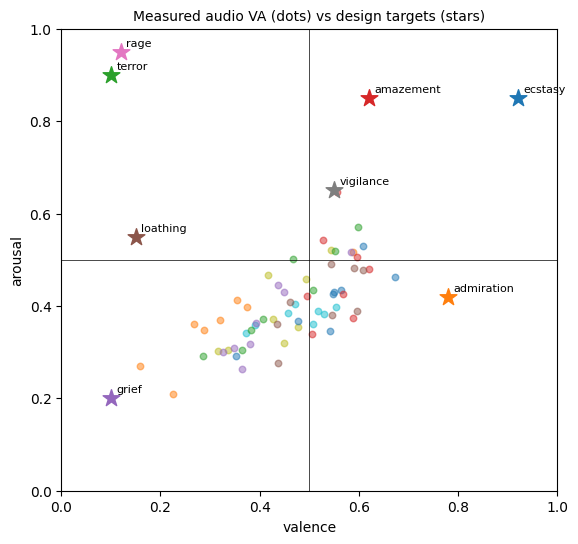

In [4]:
vadf = pipeline.rescore_and_va()

ov, by_wer = analysis.wer_summary_va(vadf)
print('FAIR WER:', {k: round(v,3) if isinstance(v,float) else v for k,v in ov.items()})
display(by_wer.round(3))

man, by_va = analysis.va_manipulation(vadf)
print('VA manipulation (audio acoustics vs design):', {k: round(v,3) for k,v in man.items()})
display(by_va.round(3))

print('VA-space LMC:', {k: round(v,4) if isinstance(v,float) else v
                        for k,v in analysis.va_congruence_summary(vadf).items()})
analysis.plot_audio_va(vadf, mock=MOCK)
import matplotlib.pyplot as plt; plt.show()

**Diagnostic — did ACE-Step honour the per-emotion tempo?** If measured BPM doesn't track the requested BPM, the emotional manipulation didn't happen *in the audio* (the likely cause: the `bpm`/`keyscale` metadata is consumed by the 5 Hz LM planner, which we disabled with `thinking=False`). This is the first thing to fix before another full run.

In [7]:
import librosa, numpy as np
rows = []
for M in emo.ORDER:
    ts = []
    for L in emo.ORDER:
        y, sr = librosa.load(str(pipeline.cell_path(L, M)), sr=22050, mono=True)
        t, _ = librosa.beat.beat_track(y=y, sr=sr); ts.append(float(t))
    rows.append({'music_emotion': M, 'requested_bpm': emo.get(M).bpm,
                 'measured_bpm': round(np.mean(ts), 1)})
bpm = pd.DataFrame(rows)
print('corr(requested, measured) =', round(np.corrcoef(bpm.requested_bpm, bpm.measured_bpm)[0,1], 3))
display(bpm)

/var/folders/17/_m9r0gbs5y1cgvcmx6mg03n80000gp/T/ipykernel_46182/4018492740.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t, _ = librosa.beat.beat_track(y=y, sr=sr); ts.append(float(t))


corr(requested, measured) = 0.229


,music_emotion,requested_bpm,measured_bpm
0,ecstasy,150,133.0
1,admiration,92,125.2
2,terror,156,116.5
3,amazement,120,123.4
4,grief,68,117.7
5,loathing,100,138.4
6,rage,168,132.7
7,vigilance,132,134.5


### 5c · A/B test — re-enable the LM planner to restore tempo control

The v2 run ignored our per-emotion tempo. Hypothesis: bpm/keyscale are applied by the 5 Hz LM planner, which we disabled. This generates grief vs rage with the planner **off vs on** and measures the resulting tempo. **Needs the ACE-Step server up.** If measured BPM tracks requested only when thinking=True, set LMCGEN_THINKING=1 and regenerate.

In [9]:
# needs the ACE-Step API server running
ab = pipeline.ab_tempo_test(emotions=("grief","rage"), thinking_values=(False, True))
display(ab)

ConnectionError: ACE-Step API server not reachable at http://127.0.0.1:8001.
Start it in a SEPARATE terminal from your ACE-Step-1.5 clone:
  cd /path/to/ACE-Step-1.5 && ./start_api_server_macos.sh
  (or: uv run python -m acestep.api_server)
The REST API listens on port 8001 by default — NOT 7860, which is the Gradio web UI and has no /release_task endpoint. Set ACESTEP_API_URL if you changed the port.

## 6 · Figures

11:39:29 | INFO | lmcgen.analysis |   figure: /Users/budge.13/Desktop/Music Analysis/analysis/output/figures/generation/lmc_heatmap_mulan.png


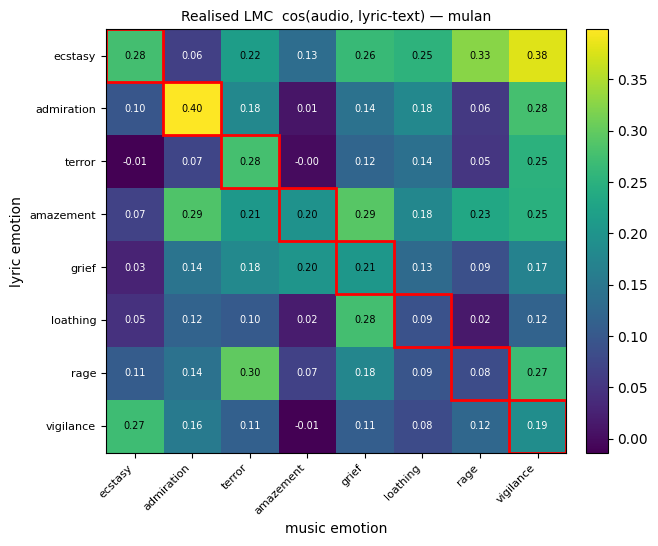

11:39:29 | INFO | lmcgen.analysis |   figure: /Users/budge.13/Desktop/Music Analysis/analysis/output/figures/generation/confusion_mulan.png


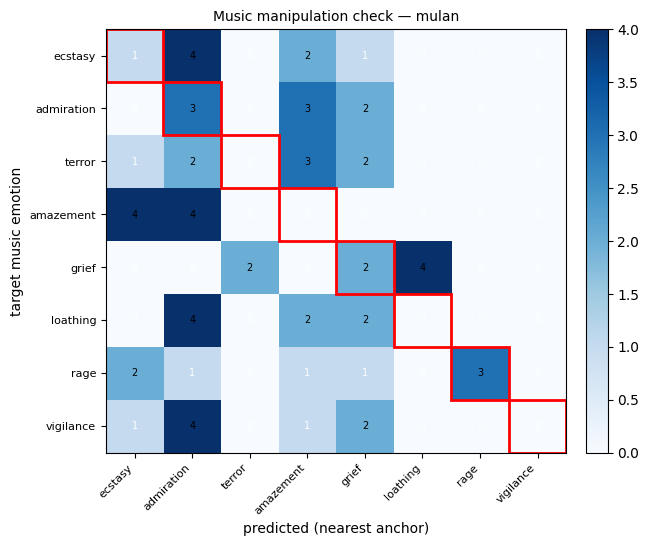

11:39:29 | INFO | lmcgen.analysis |   figure: /Users/budge.13/Desktop/Music Analysis/analysis/output/figures/generation/diagonal_vs_off.png


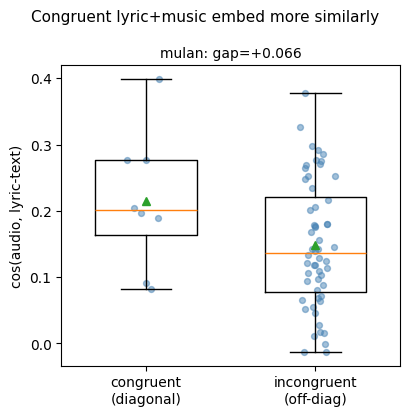

11:39:29 | INFO | lmcgen.analysis |   figure: /Users/budge.13/Desktop/Music Analysis/analysis/output/figures/generation/valence_arousal.png


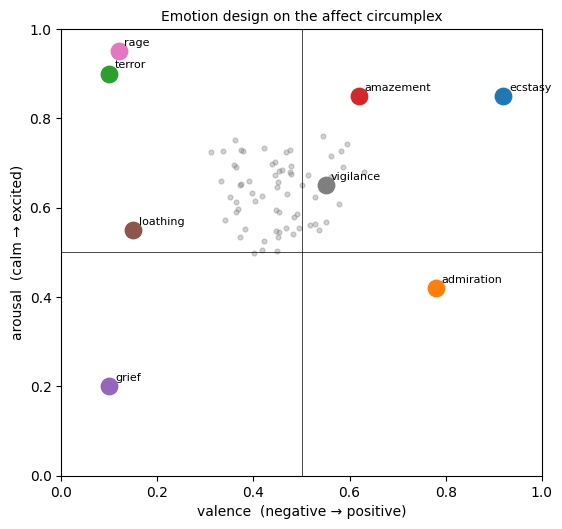

In [11]:
import matplotlib.pyplot as plt
for mk in sorted(grid["model"].unique()):
    analysis.plot_lmc_heatmap(grid, mk, mock=MOCK); plt.show()
    analysis.plot_confusion(grid, mk, mock=MOCK); plt.show()
analysis.plot_diagonal_vs_off(grid, mock=MOCK); plt.show()
analysis.plot_valence_arousal(grid, "mulan", mock=MOCK); plt.show()

## 7 · Read-out

- **Diagonal > off-diagonal** in the LMC heatmap and a positive `gap` / Cohen's *d*
  in `lmc_summary` ⇒ congruent lyric+music embed more similarly — LMC is captured.
- **Positive `congruence_gradient`** ⇒ the effect is graded, not just diagonal.
- **Confusion matrix mostly diagonal** ⇒ the music manipulation worked; blurred rows
  (e.g. admiration↔ecstasy, loathing↔rage) flag emotions music renders less distinctly.
- If **CLAP** agrees with MuLan, the result is not an artefact of tuning on MuLan.

**In dry-run these are placeholders (mock audio).** Start the ACE-Step API server
(§0), set `LMCGEN_DRY_RUN=0`, run `pipeline.clean_generated()` once, and re-run for
the real study. Outputs: `results/generation/*.csv`,
`analysis/output/figures/generation/*.png`, audio in `data/generation/audio/`.

**Toward the respondent study:** these 64 clips are the stimuli. The 8×8 design lets
you regress liking / repeat-listening on realised LMC while holding lyric content
fixed within each column and music fixed within… (see README for the modelling notes).

## 8 - Backend pilot: compare Lyria vs Suno

Generate the same hooks on two text-to-song APIs and compare lyric intelligibility (WER) and emotion accuracy (audio valence/arousal vs the design target). Set credentials first, then set LMCGEN_DRY_RUN=0.

Lyria: pip install google-genai + GEMINI_API_KEY. Suno: SUNO_API_KEY (+ SUNO_API_URL provider). Licensing: verify each covers research + stimulus sharing.

In [ ]:
# os.environ["LMCGEN_DRY_RUN"]="0"
# os.environ["GEMINI_API_KEY"]="..."     # Lyria
# os.environ["SUNO_API_KEY"]="..."        # Suno (third-party provider)
cmp = pipeline.pilot(backends=("lyria","suno"),
                     emotions=("ecstasy","grief","rage","terror"))
display(cmp.round(3))